In [72]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [73]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [74]:
df.shape

(5000, 13)

In [75]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [76]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(2)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [79]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [80]:
# Physical_Activity_Hours contain min value : Physical_Activity_Hours

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

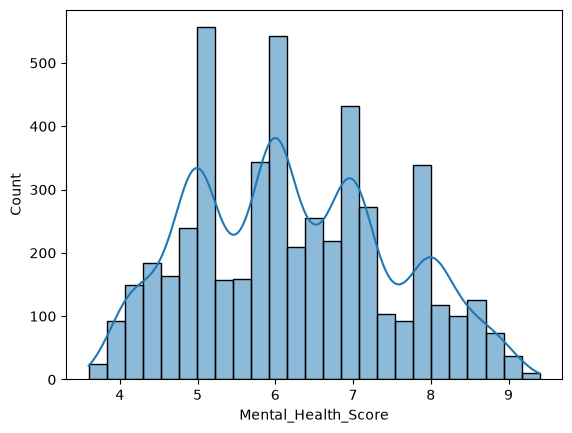

In [81]:
sns.histplot(df['Mental_Health_Score'], kde = True)   #skewness

<Axes: >

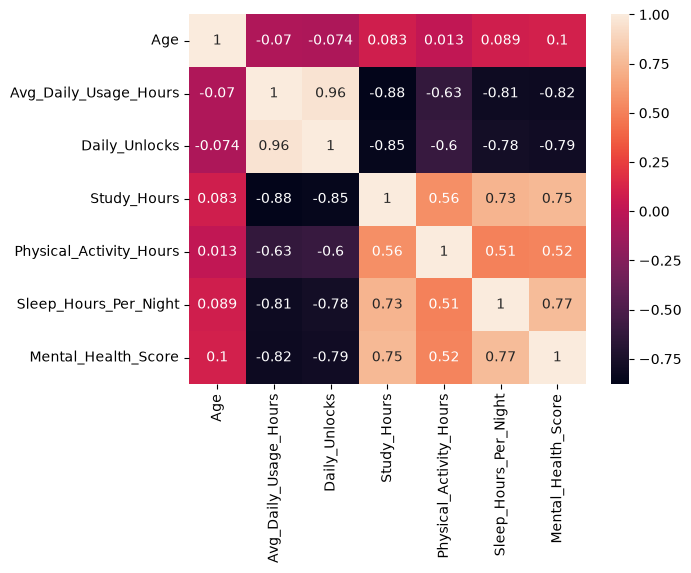

In [82]:
sns.heatmap(df.corr(numeric_only=True), annot=True)    # only work with Numeric features

In [83]:
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

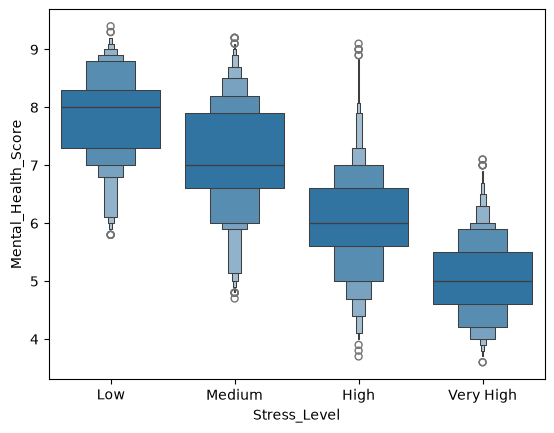

In [84]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxenplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

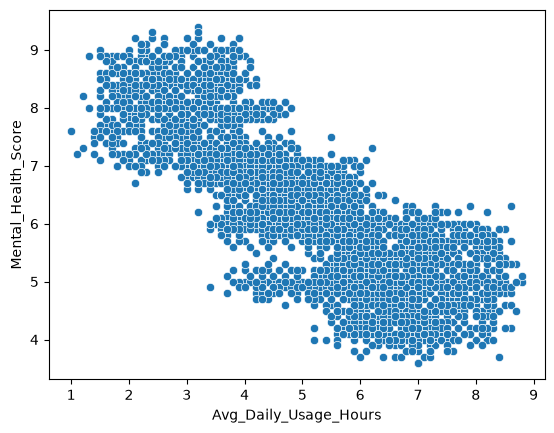

In [85]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y = 'Mental_Health_Score', data = df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

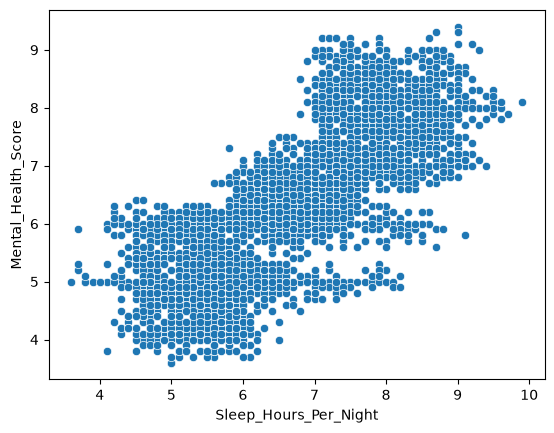

In [86]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y = 'Mental_Health_Score', data = df)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Instagram'),
  Text(1, 0, 'TikTok'),
  Text(2, 0, 'Facebook'),
  Text(3, 0, 'LinkedIn'),
  Text(4, 0, 'YouTube'),
  Text(5, 0, 'Twitter'),
  Text(6, 0, 'Snapchat'),
  Text(7, 0, 'WhatsApp'),
  Text(8, 0, 'LINE'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'KakaoTalk'),
  Text(11, 0, 'WeChat')])

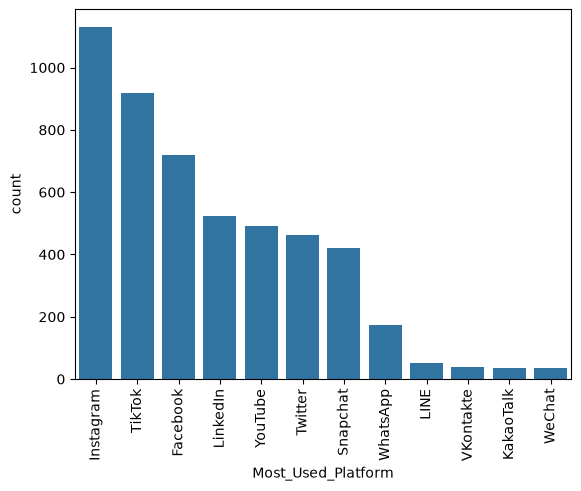

In [87]:
sns.countplot(x='Most_Used_Platform', data = df, order =df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=90)

## Checking Outlier

In [88]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [89]:
df[num_features.columns] = num_features.clip(lower_bound, upper_bound, axis=1)

In [90]:
df[num_features.columns]

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [91]:
num_features_after = df.select_dtypes(include='number')

outliers_after = (
    (num_features_after < lower_bound) |
    (num_features_after > upper_bound)
)

print(outliers_after.sum())

Age                        0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Mental_Health_Score        0
dtype: int64


In [92]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008400,1.751020,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.636953,0.666724,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.050000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.250000,3.550000,9.900000,9.400000


In [93]:
# To drop duplicate
df = df.drop_duplicates()

#converting negative value or unrealistic value to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [94]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008383,1.750880,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636767,0.666464,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.250000,3.550000,9.900000,9.400000


In [95]:
#skewness
num_clos = df.select_dtypes(include='number')
num_clos.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.435833
Physical_Activity_Hours    0.043933
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [96]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [97]:
top_contries = df['Country'].value_counts().index[:10].tolist()
top_contries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [98]:
def group_contries(country):
    if country in top_contries: 
        return country
    else: 
        return 'Other'

In [99]:
df['Grouped_countries'] = df['Country'].apply(group_contries)

In [100]:
df['Grouped_countries'].value_counts()

Grouped_countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [101]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_countries
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [102]:
df.select_dtypes(include='number').columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='str')

In [103]:
from sklearn.model_selection import train_test_split

skwewd_col = ['Study_Hours'] # we have to apply log transformation
other_numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

ordinal_col = ['Stress_Level']  # we need to do ordinal encoding 
normal_col = ['Gender','Country','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_countries']  # OHE


features_col = (skwewd_col + other_numeric_cols + ordinal_col + normal_col)
X = df[features_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1 skewed features 
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])


#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])


#3. Orinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium','High','Very High']]))
])


#4.Nominal Encoding
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline",skew_pipeline, skwewd_col),
    ("Plan_Numeric", plain_numeric_pipeline, other_numeric_cols), 
    ("Ordinal", ordinal_pipeline, ordinal_col), 
    ("Normal", nominal_pipeline, normal_col)
])

In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)


lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae =  mean_absolute_error(y_test, lr_preds)

print(f"Accuraccy of Training : {lr_r2_training}")
print(f"Accuraccy of Testing : {lr_r2_testing}")
print(f"MAE : {lr_mae}")

Accuraccy of Training : 0.7806007784332828
Accuraccy of Testing : 0.7886792808639039
MAE : 0.4745668374052335


## Random Forest 

In [106]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)


rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae =  mean_absolute_error(y_test, rf_preds)

print(f"Accuraccy of Training : {rf_r2_training}")
print(f"Accuraccy of Testing : {rf_r2_testing}")
print(f"MAE : {rf_mae}")


Accuraccy of Training : 0.986921985132021
Accuraccy of Testing : 0.9143022856521874
MAE : 0.28136225904761913


In [115]:
#Hyperparameter tunning 
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'random forest__n_estimators' : [100,200,300],
    'random forest__max_depth' : [5,10,15],
    'random forest__min_samples_split' : [2,5,100],
    'random forest__min_samples_leaf' : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring = 'r2', 
    random_state = 42, 
    n_jobs = -1    # All free processor are applied 
)


random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [116]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [117]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f" R2 Score for Rnadom forest after hyperparameter tunning {r2_score(y_test, rf_best_preds)}")
print(f" MAE Score for random forest after hyperparameter tunning {mean_absolute_error(y_test, rf_best_preds)}")

 R2 Score for Rnadom forest after hyperparameter tunning 0.897228027072932
 MAE Score for random forest after hyperparameter tunning 0.3136338803868091


In [118]:
## Model Evaluation

from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.788679     0.780601  0.474567  0.609150
1  Random Forest (default)  0.914302     0.986922  0.281362  0.387916
2    Random Forest (tuned)  0.897228     0.954751  0.313634  0.424806


In [119]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [120]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_countries']

In [121]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_countries
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [122]:
df['Academic_Level'].unique()

<ArrowStringArray>
['Undergraduate', 'Graduate', 'High School']
Length: 3, dtype: str

In [123]:
df['Most_Used_Platform'].unique()

<ArrowStringArray>
[ 'Facebook',  'LinkedIn', 'Instagram',  'Snapchat',   'Twitter',   'YouTube',
    'TikTok',      'LINE', 'KakaoTalk', 'VKontakte',  'WhatsApp',    'WeChat']
Length: 12, dtype: str

In [124]:
df['Purpose_Of_Use'].unique()

<ArrowStringArray>
['Networking', 'Education', 'Entertainment', 'News']
Length: 4, dtype: str

In [125]:
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str